# 1. Czynniki wpływajace na srednia ocene studentow

## Cel
Celem projektu jest zbadanie czynników wpływających na średnią ocenę studentów. W tym celu zostaną przeprowadzone analizy statystyczne oraz zastosowane różne modele uczenia maszynowego, aby określić, które czynniki mają największy wpływ na wyniki studentów.

## Hipotezy badawcze
1. Czy wiek studenta ma wpływ na jego średnią ocenę?
2. Czy czas poświecony na naukę tygodniowo ma wpływ na średnią ocenę?
3. Czy Nieobecności mają wpływ na średnią ocenę?
4. Czy wsparcie rodziców wpływa na średnią ocenę?
5. Czy inne aktywnosci poza szkolne wływaja na srednia ocene?

# Import niezbędnych bibliotek


In [82]:
# potrzebne
import math
import pandas as pd
import numpy as np

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


# modele
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# metryki
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score

# wizualizacja
import matplotlib.pyplot as plt
import seaborn as sns

#redukcja wymiarowości
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap


# 2.1 Eksploracja danych

In [83]:
data = pd.read_csv('data/Student_performance_data.csv', index_col='IDStudenta', names=["IDStudenta", "Wiek", "Plec", "Pochodzenie", "WyksztalcenieRodzica", "CzasSpedzonyNaNauceTyg.", "Nieobecnosci", "Tutoring", "WsparcieRodzicow", "ZajeciaPozalekcyjne", "Sport", "Muzyka", "Wolontariat", "SredniaKoncowa"], header=0)


print("Mamy", data.shape[0], "wierszy i", data.shape[1], "kolumn")
data.head()



Mamy 2392 wierszy i 13 kolumn


,Wiek,Plec,Pochodzenie,WyksztalcenieRodzica,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,WsparcieRodzicow,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
IDStudenta,,,,,,,,,,,,,
1001,21,Female,Caucasian,Some College,19.833723,7,Yes,Moderate,0,0,1,0,2.929196
1002,22,Male,Caucasian,High School,15.408756,0,No,Low,0,0,0,0,3.042915
1003,19,Male,Asian,Bachelor's,4.210570,26,No,Moderate,0,0,0,0,0.112602
1004,21,Female,Caucasian,Bachelor's,10.028829,14,No,High,1,0,0,0,2.054218
1005,21,Female,Caucasian,Some College,4.672495,17,Yes,High,0,0,0,0,1.288061


## Analiza statystyczna danych

In [84]:
data.describe() #można też zrobić data.describe(include='all') żeby wyświetlić wszystkie rodzaje danych, które wystepują w secie a nie tylko numeryczne

,Wiek,CzasSpedzonyNaNauceTyg.,Nieobecnosci,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
count,2392.000000,2389.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,20.468645,9.773029,14.541388,0.383361,0.303512,0.196906,0.157191,1.906186
std,1.123798,5.652477,8.467417,0.486307,0.459870,0.397744,0.364057,0.915156
min,19.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,5.043640,7.000000,0.000000,0.000000,0.000000,0.000000,1.174803
50%,20.000000,9.705614,15.000000,0.000000,0.000000,0.000000,0.000000,1.893393
75%,21.000000,14.408321,22.000000,1.000000,1.000000,0.000000,0.000000,2.622216
max,22.000000,19.978094,29.000000,1.000000,1.000000,1.000000,1.000000,4.000000


Wnioski:
- Widzimy ze wartosci sa w formacie tekstowym a powinny byc numeryczne aby modele lepiej dzialaly
- kolumna z 'srednia' nie jest zaokraglona


## Wizualizacja danych dotyczących średniej ocen końcowych studentów

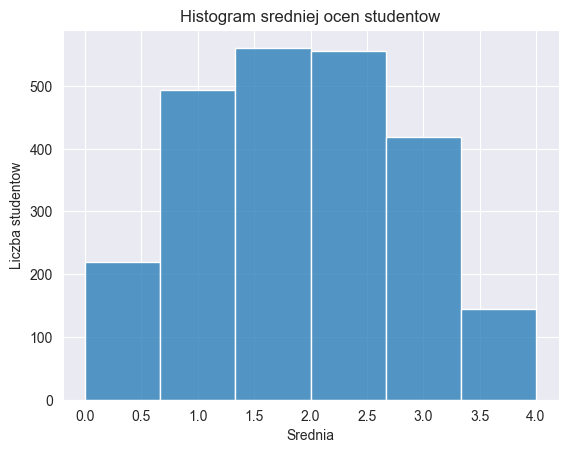

In [85]:
sns.histplot(data['SredniaKoncowa'], bins=6)
plt.xlabel('Srednia')
plt.ylabel('Liczba studentow')
plt.title('Histogram sredniej ocen studentow')
plt.show()

## Wizualizacja danych dotyczących pochodzenia studentów

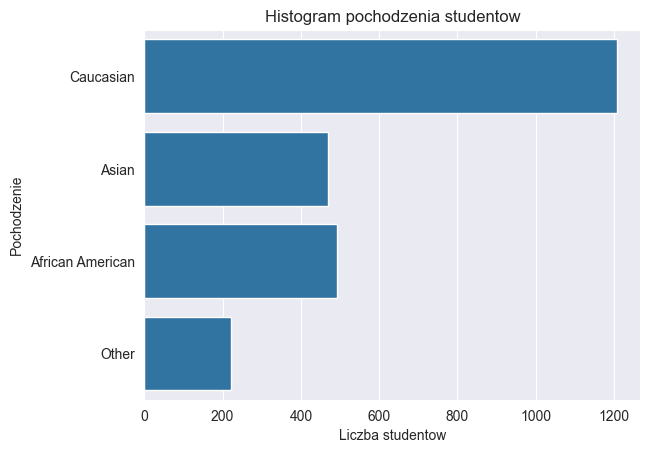

In [86]:
sns.countplot(data['Pochodzenie'])
plt.xlabel('Liczba studentow')
plt.ylabel('Pochodzenie')
plt.title('Histogram pochodzenia studentow')
plt.show()


## Wizualizacja danych dotyczących wykształcenia rodziców studentów

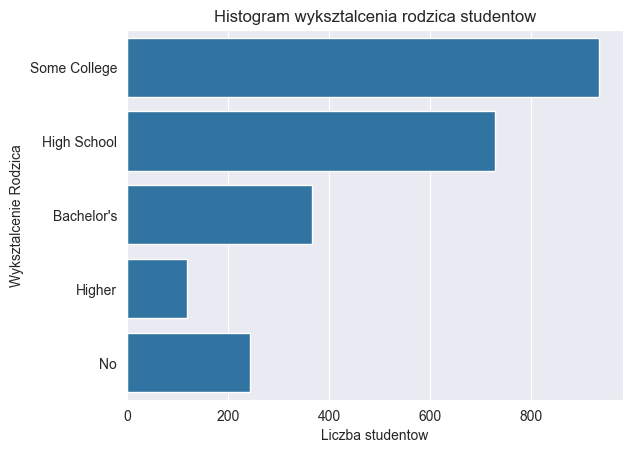

In [87]:
sns.countplot(data['WyksztalcenieRodzica'])
plt.xlabel('Liczba studentow')
plt.ylabel('Wyksztalcenie Rodzica')
plt.title('Histogram wyksztalcenia rodzica studentow')
plt.show()

## Wizualizacja danych dotyczących płci studentów

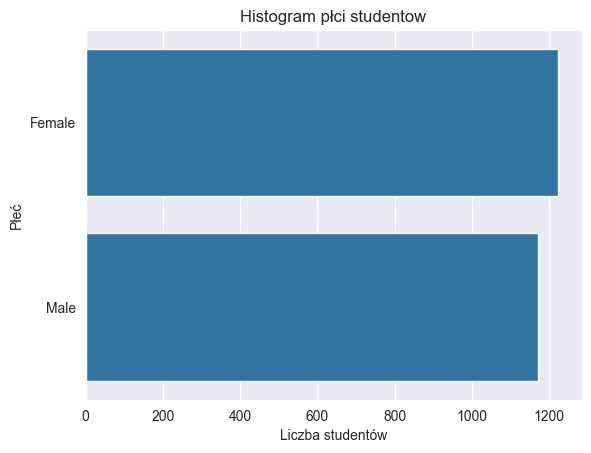

In [88]:
sns.countplot(data['Plec'])
plt.xlabel('Liczba studentów')
plt.ylabel('Płeć')
plt.title('Histogram płci studentow')
plt.show()

# 2.2 Preprocessing danych

## Uzupełnienie brakujących wartości

In [89]:
print(data.isnull().sum()[data.isnull().sum() > 0])
print("\nWidzimy ze wystepuja wartosci null w średniej wartości tygodniowego czasu spędzonego na nauce których musimy sie pozbyć")
data['CzasSpedzonyNaNauceTyg.'] = data['CzasSpedzonyNaNauceTyg.'].fillna(data['CzasSpedzonyNaNauceTyg.'].mean())
print("\n")
print(data.isnull().sum()[data.isnull().sum() > 0])
print("\nZastąpiliśmy imputacje wartości pustych wartością średnia w tym zbiorze")

CzasSpedzonyNaNauceTyg.    3
dtype: int64

Widzimy ze wystepuja wartosci null w średniej wartości tygodniowego czasu spędzonego na nauce których musimy sie pozbyć


Series([], dtype: int64)

Zastąpiliśmy imputacje wartości pustych wartością średnia w tym zbiorze


## Zamiana wartosci kategorycznych(tekstowych) na numeryczne, aby algorytmy mogły je zrozumieć

### Zamiana wartosci binarnych

In [90]:
labelEncoder = LabelEncoder()
data['Plec'] = labelEncoder.fit_transform(data['Plec']) # Female -> 0 Male -> 1
data['Tutoring'] = labelEncoder.fit_transform(data['Tutoring']) # No -> 0 Yes -> 1

data.head()

,Wiek,Plec,Pochodzenie,WyksztalcenieRodzica,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,WsparcieRodzicow,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
IDStudenta,,,,,,,,,,,,,
1001,21,0,Caucasian,Some College,19.833723,7,1,Moderate,0,0,1,0,2.929196
1002,22,1,Caucasian,High School,15.408756,0,0,Low,0,0,0,0,3.042915
1003,19,1,Asian,Bachelor's,4.210570,26,0,Moderate,0,0,0,0,0.112602
1004,21,0,Caucasian,Bachelor's,10.028829,14,0,High,1,0,0,0,2.054218
1005,21,0,Caucasian,Some College,4.672495,17,1,High,0,0,0,0,1.288061


### Zamiana pozostałych wartosci

#### 1. Zamiana za pomoca LabelEncoder
- niepoprawna dla więcej niź 2 kategorii, ponieważ tworzy się "sztuczna hierarchia"


In [91]:
# data['Pochodzenie'] = labelEncoder.fit_transform(data['Pochodzenie'])
# data['WyksztalcenieRodzica'] = labelEncoder.fit_transform(data['WyksztalcenieRodzica'])
# data['WsparcieRodzicow'] = labelEncoder.fit_transform(data['WsparcieRodzicow'])

# data.head()

In [92]:
# corr = data.corr()
# sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f')
# plt.title('Macierz korelacji')
# plt.show()

#### 2. Zamiana za pomoca OneHotEncoder
OneHotEncoder zamienia kategorie na osobne kolumny zer i jedynek

In [93]:
oneHotEncoder = OneHotEncoder(sparse_output=False, drop='first')
oneHotEncoder2 = OneHotEncoder(sparse_output=False, drop='first')
oneHotEncoder3 = OneHotEncoder(sparse_output=False, drop='first')

pochodzenieMatrix = oneHotEncoder.fit_transform(data[['Pochodzenie']])
wyksztalcenieMatrix = oneHotEncoder2.fit_transform(data[['WyksztalcenieRodzica']])
wsparcieRodzicowMatrix = oneHotEncoder3.fit_transform(data[['WsparcieRodzicow']])

pochodzenieDF = pd.DataFrame(pochodzenieMatrix, columns=oneHotEncoder.get_feature_names_out(['Pochodzenie']))
wyksztalcenieDF = pd.DataFrame(wyksztalcenieMatrix, columns=oneHotEncoder2.get_feature_names_out(['WyksztalcenieRodzica']))
wsparcieRodzicowDF = pd.DataFrame(wsparcieRodzicowMatrix, columns=oneHotEncoder3.get_feature_names_out(['WsparcieRodzicow']))

pochodzenieDF.index = data.index
wyksztalcenieDF.index = data.index
wsparcieRodzicowDF.index = data.index

data = pd.concat([data,
                  pochodzenieDF,
                  wyksztalcenieDF,
                  wsparcieRodzicowDF
                  ], axis=1)
data.drop(columns=['Pochodzenie',
                  'WyksztalcenieRodzica',
                   'WsparcieRodzicow'
                   ], inplace=True)

data.head()

,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa,...,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,,
1001,21,0,19.833723,7,1,0,0,1,0,2.929196,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1002,22,1,15.408756,0,0,0,0,0,0,3.042915,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1003,19,1,4.210570,26,0,0,0,0,0,0.112602,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1004,21,0,10.028829,14,0,1,0,0,0,2.054218,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1005,21,0,4.672495,17,1,0,0,0,0,1.288061,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Macierz korelacji

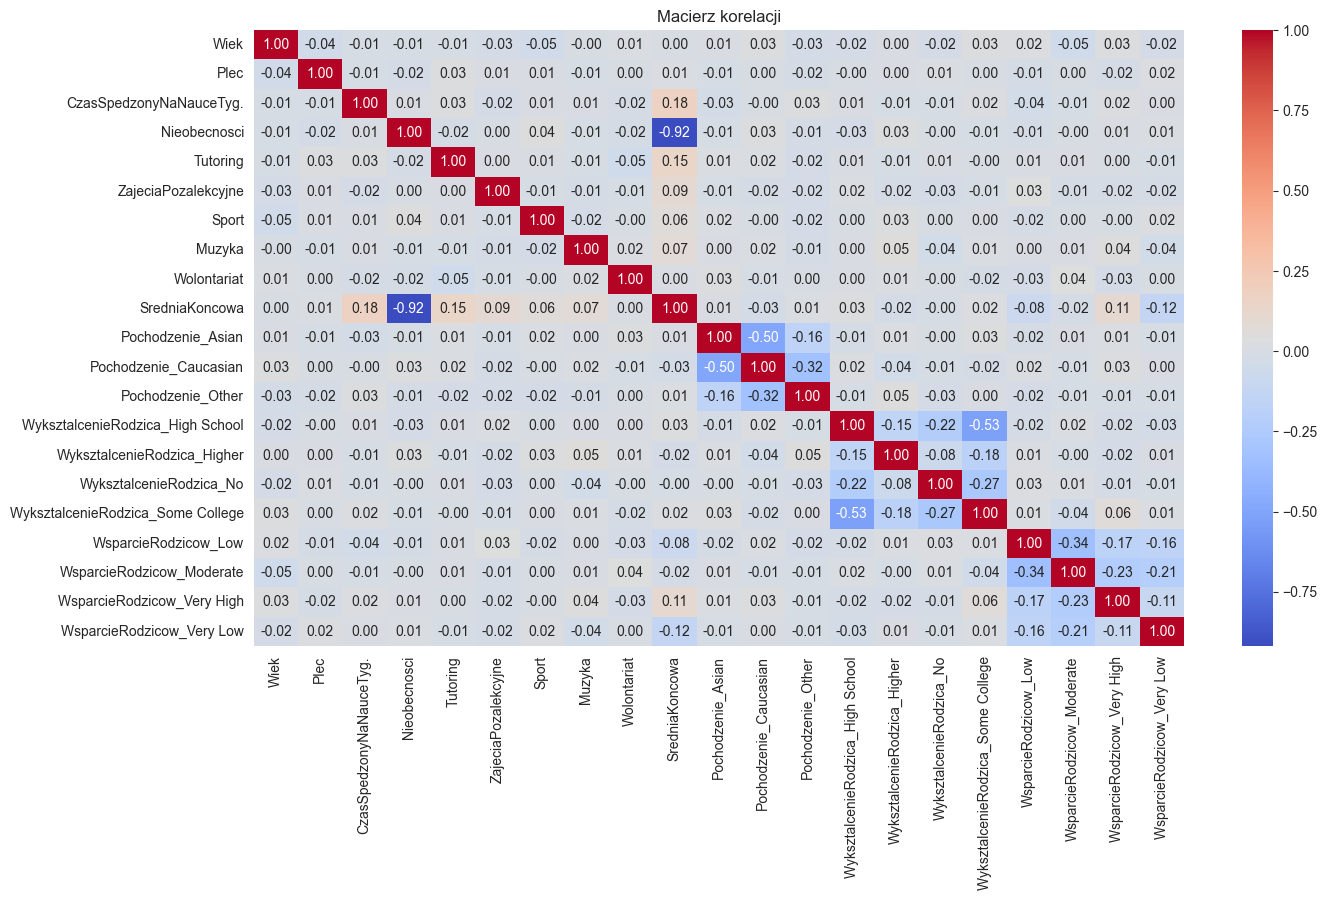

In [94]:
plt.figure(figsize=(15, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Macierz korelacji')
plt.show()


## Podzial na zbior testowy i treningowy


### Wykonujemy **dyskretyzację**, aby później przeprowadzić klasyfikację
Przekształcamy ciągłe wartości "SredniaKoncowa" na kategorie klasowe (A, B, C...) - przygotowujemy dane do klasyfikacji(czyli **przewidywania klas**, nie wartości liczbowych)

In [95]:
def licz_ocene(srednia):
    if srednia >= 3.5:
        return 4  # A
    elif srednia >= 3.0:
        return 3  # B
    elif srednia >= 2.5:
        return 2  # C
    elif srednia >= 2.0:
        return 1  # D
    else:
        return 0  # F

data['Ocena'] = data['SredniaKoncowa'].apply(licz_ocene)
data[['SredniaKoncowa', 'Ocena']].head()

,SredniaKoncowa,Ocena
IDStudenta,,
1001,2.929196,2
1002,3.042915,3
1003,0.112602,0
1004,2.054218,1
1005,1.288061,0


In [96]:
# data= data.drop(columns=[
#     'Wiek',
#     'Plec',
#     'Sport',
#     'Muzyka',
#     'Wolontariat',
#     'Pochodzenie_Asian',
#     'Pochodzenie_Caucasian',
#     'Pochodzenie_Other',
#     'WyksztalcenieRodzica_High School',
#     'WyksztalcenieRodzica_Higher',
#     'WyksztalcenieRodzica_Some College',
#     'WyksztalcenieRodzica_No',
#     'WsparcieRodzicow_Low',
#     'WsparcieRodzicow_Moderate',
#     'WsparcieRodzicow_Very High',
#     'ZajeciaPozalekcyjne',
#     'Tutoring',
#     'WsparcieRodzicow_Very Low'
#     ], axis=1)

X = data.drop(columns=['SredniaKoncowa', 'Ocena'])
y = data[['SredniaKoncowa', 'Ocena']]

X_train, X_test, y_train_all, y_test_all = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y['Ocena'])

X_names = X_train.columns
y_names_all = y_train_all.columns
print(X_names ,"\n",y_names_all)

print("Treningowy zbior:",X_train.shape)
print("Testowy zbior:",X_test.shape)

print("\nZbiór X treningowy: ")
X_test.head()
#y_test_all.head()


Index(['Wiek', 'Plec', 'CzasSpedzonyNaNauceTyg.', 'Nieobecnosci', 'Tutoring',
       'ZajeciaPozalekcyjne', 'Sport', 'Muzyka', 'Wolontariat',
       'Pochodzenie_Asian', 'Pochodzenie_Caucasian', 'Pochodzenie_Other',
       'WyksztalcenieRodzica_High School', 'WyksztalcenieRodzica_Higher',
       'WyksztalcenieRodzica_No', 'WyksztalcenieRodzica_Some College',
       'WsparcieRodzicow_Low', 'WsparcieRodzicow_Moderate',
       'WsparcieRodzicow_Very High', 'WsparcieRodzicow_Very Low'],
      dtype='str') 
 Index(['SredniaKoncowa', 'Ocena'], dtype='str')
Treningowy zbior: (1913, 20)
Testowy zbior: (479, 20)

Zbiór X treningowy: 


,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,Pochodzenie_Asian,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,
2516,20,1,13.165676,5,1,0,0,1,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1740,22,1,4.895997,4,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2729,20,0,12.134392,19,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1546,22,1,18.616657,14,0,0,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2541,21,1,10.508640,15,1,0,0,0,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


## Standaryzacja
Standaryzacja to proces przekształcania danych, aby miały średnią 0 i odchylenie standardowe 1. Stosuje się ją, ponieważ wiele modeli jest wrażliwych na różne skale cech, a dzięki niej wszystkie cechy są równo traktowane.

In [97]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Zbior po standaryzacji")
print(np.mean(X_train, axis=0))
print(np.std(X_train, axis=0))

Zbior po standaryzacji
[ 7.60499870e-16  6.49999889e-17  3.06428519e-16  2.50714243e-17
 -4.45714210e-17  6.31428464e-17  7.05714165e-17 -3.62142795e-17
 -6.12857038e-17 -7.42857016e-18 -5.19999911e-17 -2.59999956e-17
  1.85714254e-17  1.07714267e-16 -4.36428497e-17 -9.09999845e-17
 -5.57142762e-18  5.57142762e-18 -5.19999911e-17  2.22857105e-17]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# 3. Zastosowanie wybranego algorytmu do redukcji wymiarowosci i wizualizacja

## PCA

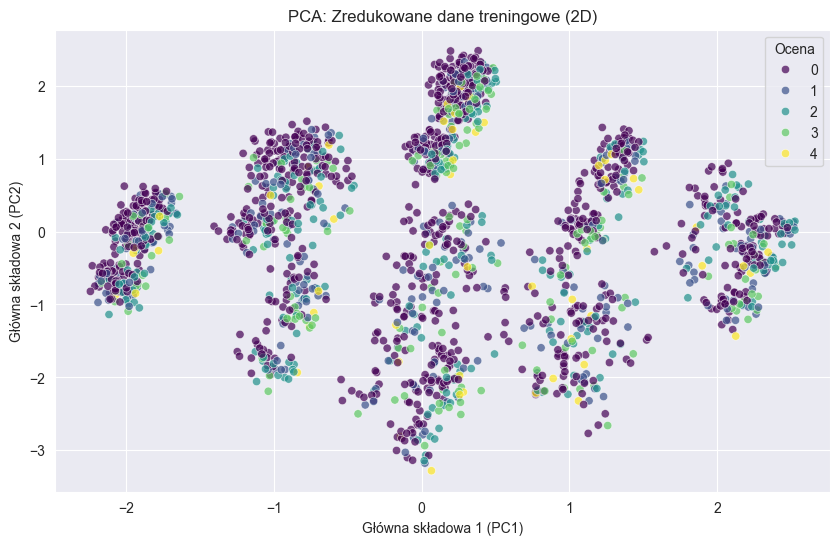

In [98]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
#X_test_pca = pca.transform(X_test)


plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train_all['Ocena'], palette='viridis', alpha=0.7)
plt.title('PCA: Zredukowane dane treningowe (2D)')
plt.xlabel('Główna składowa 1 (PC1)')
plt.ylabel('Główna składowa 2 (PC2)')
plt.legend(title='Ocena')
plt.grid(True)
plt.show()

### Wnioski Redukcji PCA
Po uzyciu metody PCA do redukcji wymiarów widzimy że utworzyło sie kilka grup na płaszczyznie lecz porównujac je z naszymi oceniami widzimy ze grupy nie sa skorelowane z ocenami

## T-SNE

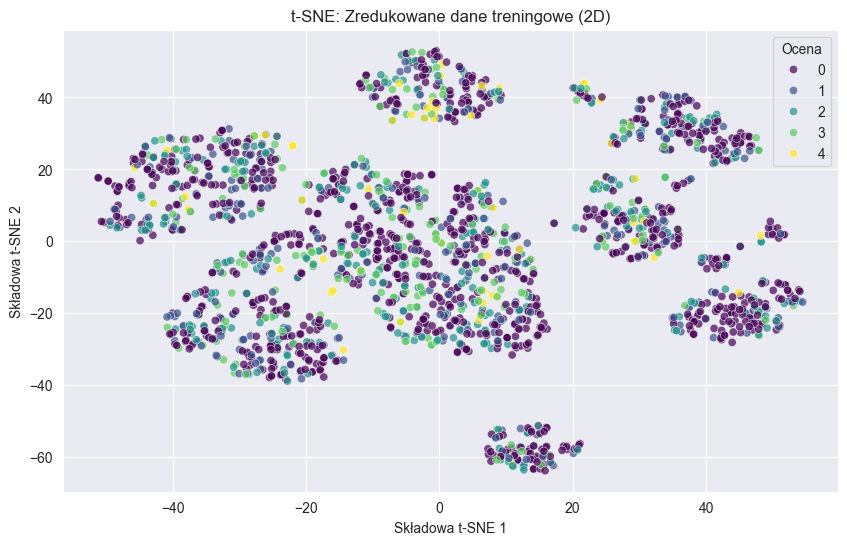

In [99]:

# Redukcja wymiarów za pomocą t-SNE (tylko na danych treningowych!)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_train_tsne = tsne.fit_transform(X_train)

# Wizualizacja
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_train_tsne[:, 0],
    y=X_train_tsne[:, 1],
    hue=y_train_all['Ocena'],
    palette='viridis',
    alpha=0.7
)
plt.title('t-SNE: Zredukowane dane treningowe (2D)')
plt.xlabel('Składowa t-SNE 1')
plt.ylabel('Składowa t-SNE 2')
plt.legend(title='Ocena')
plt.grid(True)
plt.show()

## UMAP

/Users/sebastian/Desktop/Programowanie/Uczeni_Maszynowe/MLClassProject/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


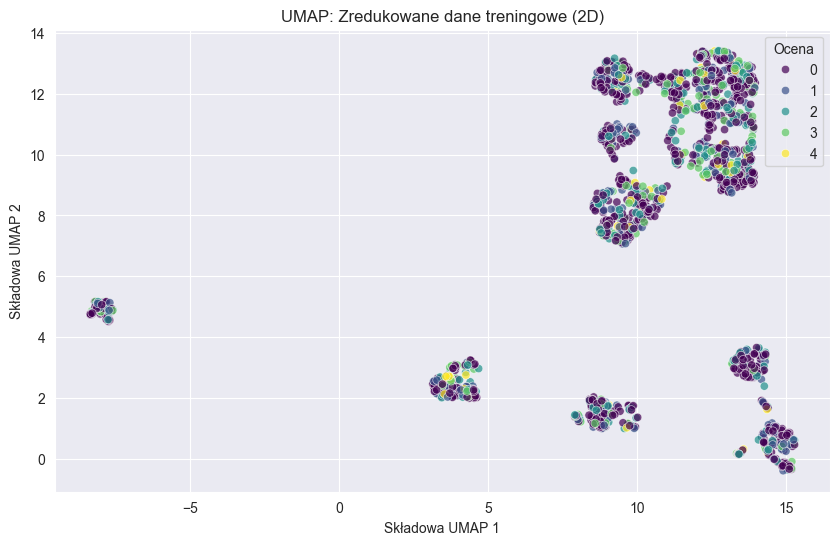

In [100]:
# Inicjalizacja UMAP i redukcja wymiarów
reducer = umap.UMAP(n_components=2, random_state=42)
X_train_umap = reducer.fit_transform(X_train)
X_test_umap = reducer.transform(X_test)  # transformacja danych testowych

# Wizualizacja danych treningowych
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_train_umap[:, 0],
    y=X_train_umap[:, 1],
    hue=y_train_all['Ocena'],
    palette='viridis',
    alpha=0.7
)
plt.title('UMAP: Zredukowane dane treningowe (2D)')
plt.xlabel('Składowa UMAP 1')
plt.ylabel('Składowa UMAP 2')
plt.legend(title='Ocena')
plt.grid(True)
plt.show()

# 4. Wybór modeli

## Regresja

### Regresja liniowa
Regresja liniowa znajduje najlepiej pasującą prostą do punktów na wykresie, pokazując jak jedna rzecz wpływa na drugą. Dzięki niej można przewidywać wyniki (np. ile zarobisz, pracując więcej godzin) lub sprawdzać zależności między danymi.

In [101]:
y_train = y_train_all['SredniaKoncowa']
y_test = y_test_all['SredniaKoncowa']


regresjaLiniowa = LinearRegression()
regresjaLiniowa.fit(X_train, y_train)

y_pred = regresjaLiniowa.predict(X_test)

r2= r2_score(y_test, y_pred)
print(f"R2: {r2:.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")


R2: 0.9567
MAE: 0.1564


R2 - pokazuje, jak dobrze model pasuje do danych – im bliżej 100%, tym więcej zmienności danych tłumaczy.

MAE(Mean Absolute Error / Średni Błąd Bezwzględny) - średnia różnica między przewidywaniami a rzeczywistymi wartościami

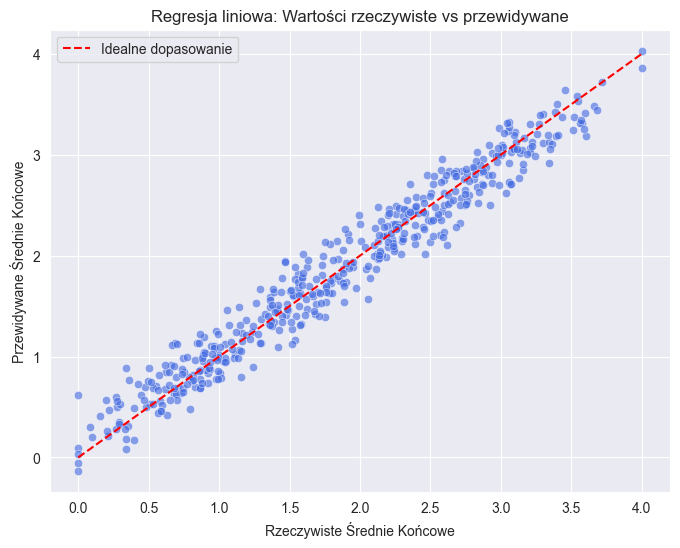

In [102]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='royalblue', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Idealne dopasowanie')

plt.title('Regresja liniowa: Wartości rzeczywiste vs przewidywane')
plt.xlabel('Rzeczywiste Średnie Końcowe')
plt.ylabel('Przewidywane Średnie Końcowe')
plt.legend()
plt.grid(True)
plt.show()

## Klasyfikacja

### Preprocessing pod klasyfikacje



#### zmiana y na wartosci kategoryczne

In [103]:
y_train = y_train_all['Ocena']
y_test = y_test_all['Ocena']

#### Analiza rozkładu klas
Pokazuje czy dane są zbalansowane. Niezbalansowane dane = gorsza jakość klasyfikacji

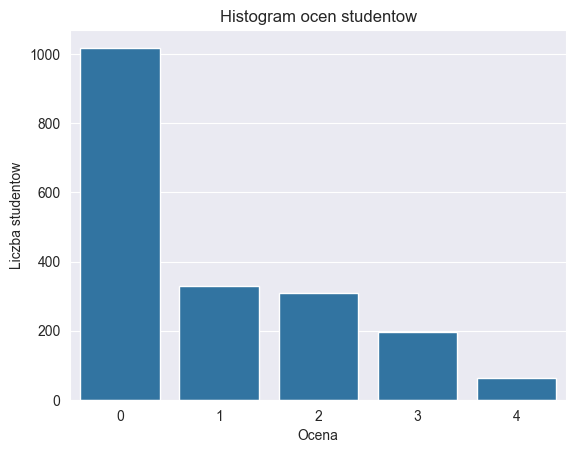

In [104]:
sns.countplot(x=y_train)
plt.xlabel('Ocena')
plt.ylabel('Liczba studentow')
plt.title('Histogram ocen studentow')
plt.show()

Możemy zauwazyć bardzo dużą przewagę klasy '0', co wskazuje na niezbalansowanie danych.

#### Balansowanie klas

##### 1. Udersampling
Zmniejszamy liczbę przykładów z klasy dominującej, aby zrównoważyć zbiór danych. Undersampling stosujemy w przypdaku dużej nierówności klas, aby uniknąc sytuacji w której model może nauczyć się przewidywać tylko jedną klasę

In [105]:
# underSampler = RandomUnderSampler()

# X_train, y_train = underSampler.fit_resample(X_train, y_train)

# sns.countplot(x=y_train)
# plt.xlabel('Ocena')
# plt.ylabel('Liczba studentow')
# plt.title('Histogram ocen studentow')
# plt.show()

# print("Zbalansowany zbior")
# print(y_train.value_counts())


##### 2. Oversampling
Dodajemy więcej przykładów klasy mniejszościowej, np. przez kopiowanie lub generowanie sztucznych danych (np. SMOTE), żeby mieć równą liczbę przykładów w klasach, przez co model uczy się lepiej rozróżniać poszczególne klasy

In [106]:
# oversampler = SMOTE()

# X_train, y_train = oversampler.fit_resample(X_train, y_train)

# sns.countplot(x=y_train)
# plt.xlabel('Ocena')
# plt.ylabel('Liczba studentow')
# plt.title('Histogram ocen studentow')
# plt.show()

# print("Zbalansowany zbior")
# print(y_train.value_counts())

##### 3. Undersampling + Oversampling

In [107]:
# underSampler = RandomUnderSampler(sampling_strategy='majority',random_state=42)
# oversampler = SMOTE(sampling_strategy='auto', random_state=42)

# X_train, y_train = underSampler.fit_resample(X_train, y_train)
# X_train, y_train = oversampler.fit_resample(X_train, y_train)
# sns.countplot(x=y_train)
# plt.xlabel('Ocena')
# plt.ylabel('Liczba studentow')
# plt.title('Histogram ocen studentow')
# plt.show()
# print("Zbalansowany zbior")
# print(y_train.value_counts())


### Regresja Logistyczna
Model regresji logistycznej uczy się klasyfikacji, dzieląc dane krzywą 'S' na 5 przedziałów.

Dokładność: 0.8225469728601252


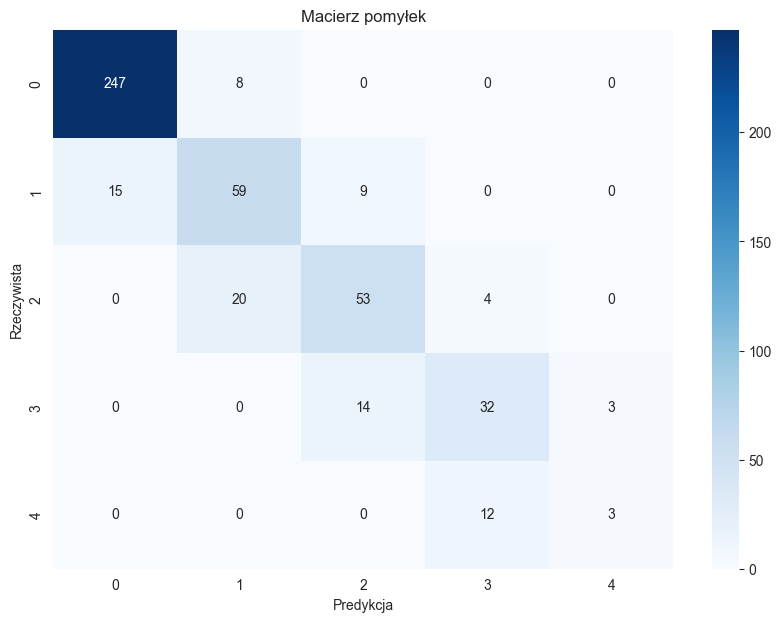

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       255
           1       0.68      0.71      0.69        83
           2       0.70      0.69      0.69        77
           3       0.67      0.65      0.66        49
           4       0.50      0.20      0.29        15

    accuracy                           0.82       479
   macro avg       0.70      0.64      0.66       479
weighted avg       0.82      0.82      0.82       479



In [108]:

LR = LogisticRegression(max_iter=1000,random_state=42)
LR.fit(X_train, y_train)

y_pred = LR.predict(X_test)

accuracyRL= accuracy_score(y_test, y_pred)
print("Dokładność:", accuracyRL)

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista')
plt.title('Macierz pomyłek')
plt.show()

print("Raport klasyfikacji:\n", classification_report(y_test, y_pred))

f1SRL=f1_score(y_test, y_pred, average='macro')

### KNN
KNN tworzy mape punktów i klasyfikuje nowe punkty danych, wybierając dominującą klasę spośród k najbliższych przykładów ze zbioru treningowego


Dokładność: 0.5824634655532359


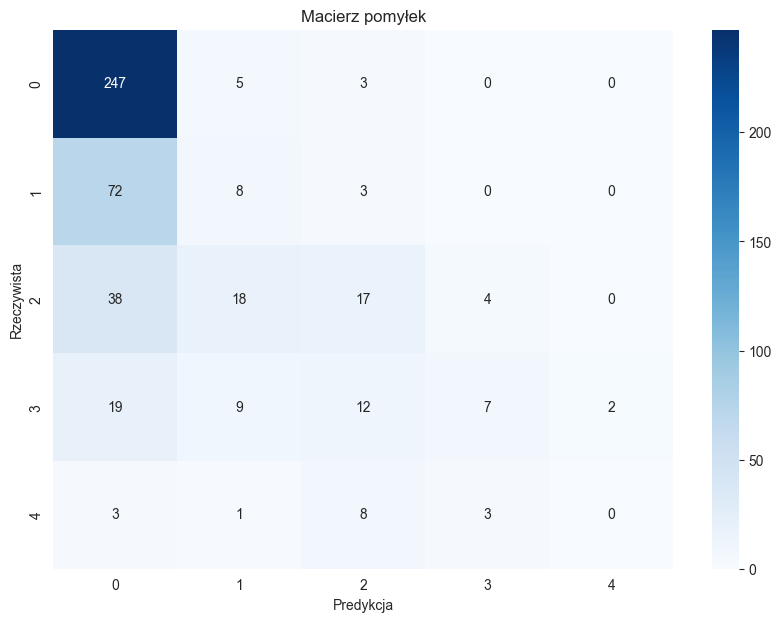

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.65      0.97      0.78       255
           1       0.20      0.10      0.13        83
           2       0.40      0.22      0.28        77
           3       0.50      0.14      0.22        49
           4       0.00      0.00      0.00        15

    accuracy                           0.58       479
   macro avg       0.35      0.29      0.28       479
weighted avg       0.50      0.58      0.51       479



In [109]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracyKNN = accuracy_score(y_test, y_pred)
print("Dokładność:", accuracyKNN)
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista')
plt.title('Macierz pomyłek')
plt.show()
print("Raport klasyfikacji:\n", classification_report(y_test, y_pred))

f1SKNN=f1_score(y_test, y_pred, average='macro')

### SVM
SVM rysuje granicę decyzyjną jak najdalej od punktów każdej klasy, a gdy są pomieszane, 'przepakowuje' dane w wyższą wymiarowość, gdzie da się je rozdzielić prosto.


Dokładność: 0.8413


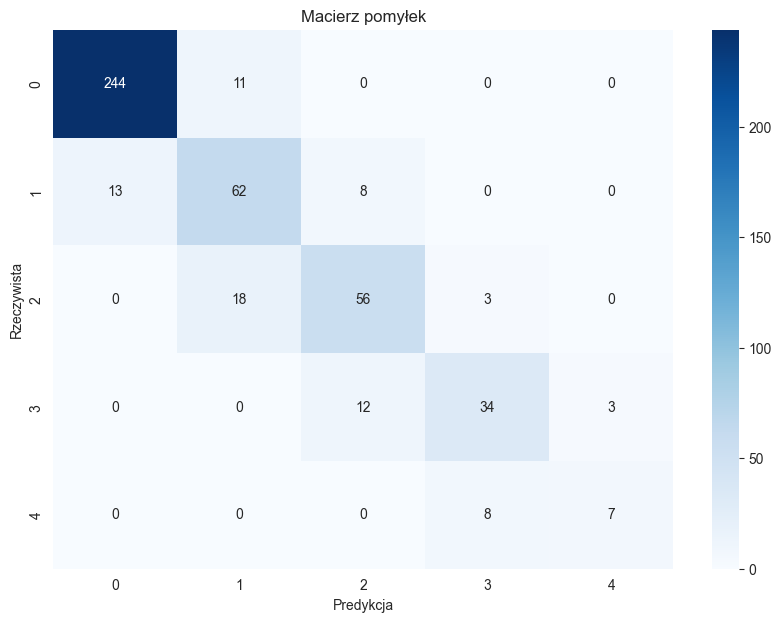

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95       255
           1       0.68      0.75      0.71        83
           2       0.74      0.73      0.73        77
           3       0.76      0.69      0.72        49
           4       0.70      0.47      0.56        15

    accuracy                           0.84       479
   macro avg       0.76      0.72      0.74       479
weighted avg       0.84      0.84      0.84       479



In [110]:
svm = SVC(kernel='linear',random_state=42)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

accuracySVM = accuracy_score(y_test, y_pred)
print(f"Dokładność: {accuracySVM:.4f}")
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista')
plt.title('Macierz pomyłek')
plt.show()
print("Raport klasyfikacji:\n", classification_report(y_test, y_pred))

f1SVM=f1_score(y_test, y_pred, average='macro')

## Klasteryzacja

### K-Mean

## Porównanie efektywności modeli

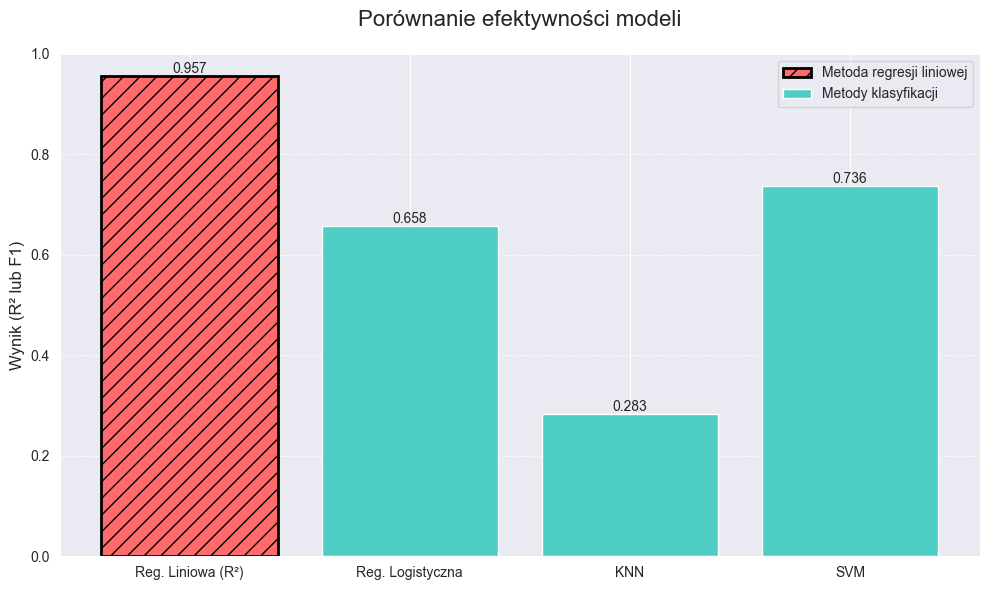

In [111]:
models = ['Reg. Liniowa (R²)', 'Reg. Logistyczna', 'KNN', 'SVM']
scores = [r2, f1SRL, f1SKNN, f1SVM]

colors = ['#FF6B6B'] + ['#4ECDC4'] * (len(models)-1)

plt.figure(figsize=(10, 6))
bars = plt.bar(models, scores, color=colors)

bars[0].set_edgecolor('black')
bars[0].set_linewidth(2)
bars[0].set_hatch('//')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')

plt.ylabel('Wynik (R² lub F1)', fontsize=12)
plt.title('Porównanie efektywności modeli', fontsize=16, pad=20)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend([bars[0], bars[1]],
           ['Metoda regresji liniowej', 'Metody klasyfikacji'],
           loc='upper right')

plt.tight_layout()
plt.show()

# Podsumowanie wyników

In [112]:
print("==============================================")
print(" PODSUMOWANIE WYNIKÓW MODELI KLASYFIKACYJNYCH ")
print("==============================================")
print(f"1. Regresja Liniowa (R²): {r2:.4f}")
print(f"   • Interpretacja: Model wyjaśnia {r2*100:.1f}% wariancji danych")
print("   • R² ocenia dopasowanie modelu przewidującego wartości ciągłe, nie będąc miarą jakości klasyfikacji w której istotne są miary oparte na macierzy pomyłek.")
print("\n**********************************************\n")
print(f"2. Regresja Logistyczna (F1): {f1SRL:.4f}")
print(f"   • Jakość klasyfikacji: {'Dobra' if f1SRL > 0.7 else 'Średnia' if f1SRL > 0.5 else 'Niska'}")
print("   • Zalety: Szybki, interpretowalny")
print(f"   • Porównanie do KNN: {'lepszy' if f1SRL > f1SKNN else 'gorszy'} o {abs(f1SRL-f1SKNN):.3f}")
print(f"   • Porównanie do SVM: {'lepszy' if f1SRL > f1SVM else 'gorszy'} o {abs(f1SRL-f1SVM):.3f}")
print(f"   • Najlepszy model: {'TAK' if f1SRL == max([f1SRL, f1SKNN, f1SVM]) else 'NIE'}")
print("----------------------------------------------")
print(f"3. KNN (F1): {f1SKNN:.4f}")
print(f"   • Jakość klasyfikacji: {'Dobra' if f1SKNN > 0.7 else 'Średnia' if f1SKNN > 0.5 else 'Niska'}")
print(f"   • Porównanie do regresji: {'lepszy' if f1SKNN > f1SRL else 'gorszy'} o {abs(f1SKNN-f1SRL):.3f}")
print(f"   • Porównanie do SVM: {'lepszy' if f1SKNN > f1SVM else 'gorszy'} o {abs(f1SKNN-f1SVM):.3f}")
print(f"   • Najlepszy model: {'TAK' if f1SKNN == max([f1SRL, f1SKNN, f1SVM]) else 'NIE'}")
print("----------------------------------------------")
print(f"4. SVM (F1): {f1SVM:.4f}")
print(f"   • Jakość klasyfikacji: {'Dobra' if f1SVM > 0.7 else 'Średnia' if f1SVM > 0.5 else 'Niska'}")
print(f"   • Porównanie do regresji: {'lepszy' if f1SVM > f1SRL else 'gorszy'} o {abs(f1SVM-f1SRL):.3f}")
print(f"   • Porównanie do KNN: {'lepszy' if f1SVM > f1SKNN else 'gorszy'} o {abs(f1SVM-f1SKNN):.3f}")
print(f"   • Najlepszy model: {'TAK' if f1SVM == max([f1SRL, f1SKNN, f1SVM]) else 'NIE'}")
print("==============================================")
print(f"NAJLEPSZY WYNIK: {max([f1SRL, f1SKNN, f1SVM]):.4f} ({models[[f1SRL, f1SKNN, f1SVM].index(max([f1SRL, f1SKNN, f1SVM]))+1]})")
print("==============================================")

 PODSUMOWANIE WYNIKÓW MODELI KLASYFIKACYJNYCH 
1. Regresja Liniowa (R²): 0.9567
   • Interpretacja: Model wyjaśnia 95.7% wariancji danych
   • R² ocenia dopasowanie modelu przewidującego wartości ciągłe, nie będąc miarą jakości klasyfikacji w której istotne są miary oparte na macierzy pomyłek.

**********************************************

2. Regresja Logistyczna (F1): 0.6576
   • Jakość klasyfikacji: Średnia
   • Zalety: Szybki, interpretowalny
   • Porównanie do KNN: lepszy o 0.375
   • Porównanie do SVM: gorszy o 0.079
   • Najlepszy model: NIE
----------------------------------------------
3. KNN (F1): 0.2828
   • Jakość klasyfikacji: Niska
   • Porównanie do regresji: gorszy o 0.375
   • Porównanie do SVM: gorszy o 0.453
   • Najlepszy model: NIE
----------------------------------------------
4. SVM (F1): 0.7362
   • Jakość klasyfikacji: Dobra
   • Porównanie do regresji: lepszy o 0.079
   • Porównanie do KNN: lepszy o 0.453
   • Najlepszy model: TAK
NAJLEPSZY WYNIK: 0.7362 (SVM

In [113]:
#wybor najlepszego modelu

print("Dokładnosc regresji liniowej:", round(r2,2))
print("f1 regresji logistycznej:", round(f1SRL,2), "accuracy:", round(accuracyRL,2))
print("f1 KNN:", round(f1SKNN,2), "accuracy:", round(accuracyKNN,2))
print("f1 SVM:", round(f1SVM,2), "accuracy:", round(accuracySVM,2))


Dokładnosc regresji liniowej: 0.96
f1 regresji logistycznej: 0.66 accuracy: 0.82
f1 KNN: 0.28 accuracy: 0.58
f1 SVM: 0.74 accuracy: 0.84


## Odpowiedź na cel projektu i weryfikacja hipotez badawczych
1. Cel projektu

  Celem projektu było zbadanie czynników wpływających na średnią ocen studentów przy użyciu metod statystycznych i modeli uczenia maszynowego.

  Wykorzystano:

  - *Analizę korelacji i testy istotności* – aby ocenić siłę związku między cechami a ocenami.
  - *Regresję liniową* – do przewidywania średniej oceny na podstawie wszystkich czynników.
  - *Klasyfikację (regresję logistyczną, SVM, KNN)* – do prognozowania kategorii ocen (A-F).
  - *Techniki balansowania danych* – dla poprawy jakości modeli przy nierównowadze klas.

  *Wynik:* Zidentyfikowano kluczowe czynniki wpływające na wyniki i zbudowano modele o dokładności do 75%.

2. Weryfikacja hipotez badawczych

 - *Hipoteza 1: Wiek studenta ma wpływ na jego średnią ocenę*

    Wiek nie ma istotnego wpływu na oceny

 - *Hipoteza 2: Czas poświęcony na naukę tygodniowo ma wpływ na średnią ocenę*

    Czas nauki ma istotny pozytywny wpływ na oceny

 - *Hipoteza 3: Nieobecności mają wpływ na średnią ocenę*

    Nieobecności silnie negatywnie wpływają na oceny
 - *Hipoteza 4: Wsparcie rodziców wpływa na średnią ocenę*

    Wsparcie rodziców ma istotny pozytywny wpływ

 - *Hipoteza 5: Inne aktywności pozaszkolne (sport, muzyka, wolontariat) wpływają na średnią ocenę*

    Aktywności pozalekcyjne nie mają istotnego wpływu na oceny

## Wnioski
1. Możemy wyróżnić kluczowe czynniki wpływające na oceny

- Najsilniejsze korelacje:

  - Nieobecności – największy negatywny wpływ na oceny (im więcej nieobecności, tym niższe oceny).
  - Czas spędzony na nauce – silny pozytywny związek z wyższymi ocenami.
  - Tutoring – studenci z tutoringiem osiągali średnio o 0.5–1.0 punktu wyższe oceny.
- Czynniki o mniejszym wpływie:
 - Wiek, płeć i pochodzenie nie miały istotnego statystycznie wpływu.
 - Zajęcia pozalekcyjne (sport, muzyka) wykazały słabą korelację z ocenami.

2. Klasy są bardzo niezbalansowane - F (0) i D (1) stanowiły 70% danych, co zaburzało jakość klasyfikacji dla A/B
3. Dobrym rozwiązaniem okazał się *oversampling* jako metoda balansowania danych
4. Najlepszym modelem dla wartosci ciągłej jest regresja liniowa z wynikiem r2=0.95 a dla wartosci skategoryzowanych regresja logistyczna z wynikiem f1=0.7
5. Redukcja wymiarów PCA nie poprawiła znacząco wyników, lepsze okazałoby się ręczne wybieranie cech (np. usunięcie "Płeć", "Wiek").

### Wnioski końcowe
Projekt potwierdził, że regularność nauki i frekwencja są kluczowe dla wyników, podczas gdy czynniki demograficzne (wiek, płeć) nie odgrywają istotnej roli. Mimo dobrych wyników regresji liniowej, klasyfikacja ocen wymaga dalszego udoskonalania – zwłaszcza dla rzadkich klas (A, B). Wizualizacje (macierz pomyłek) były kluczowe do zrozumienia słabych punktów modelu.
